In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Bộ tứ mô hình
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from prophet import Prophet

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')
print("✅ Đã sẵn sàng bộ tứ: XGBoost, RF, LightGBM và Prophet!")

✅ Đã sẵn sàng bộ tứ: XGBoost, RF, LightGBM và Prophet!


In [73]:
def business_eval(y_true, y_pred, model_name):
    y_true = np.maximum(y_true, 1e-7)
    mae = mean_absolute_error(y_true, y_pred)
    
    # WAPE: Sai số phần trăm trọng số (Chuẩn ngành bán lẻ)
    wape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100
    
    # BIAS: Độ lệch dự báo (Âm là thiếu hàng, Dương là thừa hàng)
    bias = ((np.sum(y_pred) - np.sum(y_true)) / np.sum(y_true)) * 100
    accuracy = 100 - wape
    
    return {
        "Model": model_name,
        "Độ chính xác (%)": round(accuracy, 2),
        "WAPE (%)": round(wape, 2),
        "BIAS (%)": round(bias, 2),
        "MAE (Sản phẩm)": round(mae, 2)
    }

# Load dữ liệu sạch
df = pd.read_csv('../data/processed/clean_retail_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
print(f"📊 Đã nạp {df.shape[0]} bản ghi.")

📊 Đã nạp 72300 bản ghi.


In [74]:
# Chọn SKU bán chạy nhất làm mẫu so sánh
target_sku = df['Identity'].value_counts().index[0]
df_target = df[df['Identity'] == target_sku].sort_values('Date')

# 1. Biến cho nhóm Regression (XGB, RF, LGBM)
features = ['Price', 'Discount', 'Inventory Level', 'Lag_1', 'Lag_7', 
            'Rolling_Mean_7', 'Inventory_Stress', 'Sales_Velocity', 'Month', 'Is_Weekend']
categorical = ['Region', 'Weather Condition']

X = pd.get_dummies(df_target[features + categorical], columns=categorical, drop_first=True)
y = np.log1p(df_target['Units Sold']) 

# Tách tập Test 30 ngày cuối (không shuffle để giữ tính thời gian)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=30, shuffle=False)
y_test_real = np.expm1(y_test)

print(f"🎯 Đang tập trung dự báo cho SKU: {target_sku}")

🎯 Đang tập trung dự báo cho SKU: Groceries-P0016


In [75]:
results = [] # Reset kết quả

reg_models = {
    "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=500, learning_rate=0.05, verbose=-1)
}

print("⏳ Đang huấn luyện nhóm Regression...")
for name, model in reg_models.items():
    model.fit(X_train, y_train)
    y_p = np.expm1(model.predict(X_test))
    results.append(business_eval(y_test_real, y_p, name))
    print(f"✅ {name} đã hoàn thành.")

⏳ Đang huấn luyện nhóm Regression...
✅ XGBoost đã hoàn thành.
✅ Random Forest đã hoàn thành.
✅ LightGBM đã hoàn thành.


In [76]:
print(f"⏳ Đang chạy Prophet cho SKU: {target_sku}...")

# Chuẩn bị ds, y và regressors
df_p = df_target[['Date', 'Units Sold', 'Price', 'Discount']].rename(columns={'Date': 'ds', 'Units Sold': 'y'})
train_p = df_p.iloc[:-30]
test_p = df_p.iloc[-30:]

# Cấu hình Prophet chuyên sâu
m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
m.add_regressor('Price')
m.add_regressor('Discount')

m.fit(train_p)

# Dự báo 30 ngày kèm dữ liệu tương lai
future = m.make_future_dataframe(periods=30)
future = future.merge(df_p[['ds', 'Price', 'Discount']], on='ds', how='left').fillna(method='ffill')

forecast = m.predict(future)
y_p_prophet = forecast.iloc[-30:]['yhat'].values

results.append(business_eval(test_p['y'], y_p_prophet, "Prophet (SKU-Level)"))
print("✅ Prophet đã hoàn thành.")

20:24:34 - cmdstanpy - INFO - Chain [1] start processing
20:24:34 - cmdstanpy - INFO - Chain [1] done processing


⏳ Đang chạy Prophet cho SKU: Groceries-P0016...
✅ Prophet đã hoàn thành.



📊 BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH CHI TIẾT


,Model,Độ chính xác (%),WAPE (%),BIAS (%),MAE (Sản phẩm)
0,XGBoost,52.29,47.71,-29.08,75.20
2,LightGBM,50.60,49.40,-16.63,77.85
3,Prophet (SKU-Level),48.67,51.33,-35.78,80.90
1,Random Forest,47.91,52.09,-37.98,82.09


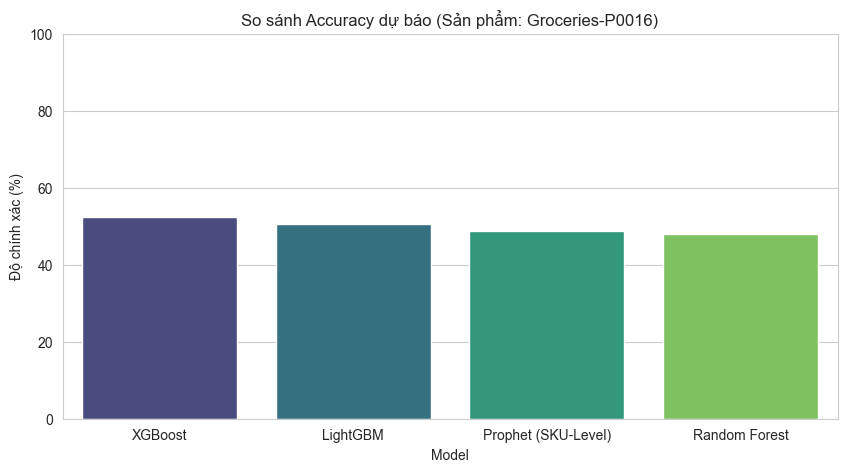

In [77]:
if len(results) > 0:
    report_df = pd.DataFrame(results).sort_values(by="Độ chính xác (%)", ascending=False)
    print("\n" + "="*60)
    print("📊 BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH CHI TIẾT")
    print("="*60)
    display(report_df)

    # Biểu đồ Accuracy
    plt.figure(figsize=(10, 5))
    sns.barplot(data=report_df, x='Model', y='Độ chính xác (%)', palette='viridis')
    plt.title(f'So sánh Accuracy dự báo (Sản phẩm: {target_sku})')
    plt.ylim(0, 100)
    plt.show()
else:
    print("❌ Chưa có kết quả, kiểm tra lại các bước trên!")

In [78]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV

print("🏆 Đang triển khai mô hình kết hợp STACKING (XGB + RF + LGBM + Prophet)...")

# 1. Lấy dự báo từ Prophet cho cả tập Train và Test (vì Prophet không dùng cấu trúc X, y thông thường)
# (Bước này giả định bạn đã có y_p_prophet từ Cell 5)

# 2. Tạo tập dữ liệu mới từ dự báo của các mô hình cơ sở
# Để đơn giản và hiệu quả nhất, chúng ta dùng Stacking của 3 thằng Regression trước
base_estimators = [
    ('xgb', XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6)),
    ('rf', RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1)),
    ('lgbm', LGBMRegressor(n_estimators=500, learning_rate=0.05, verbose=-1))
]

# Mô hình trọng tài (Final Estimator) dùng Ridge Regression để tổng hợp
stacking_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=RidgeCV(),
    cv=5
)

# 3. Huấn luyện mô hình kết hợp
stacking_model.fit(X_train, y_train)

# 4. Dự báo và đánh giá
y_p_stack_log = stacking_model.predict(X_test)
y_p_stack = np.expm1(y_p_stack_log)

stack_results = business_eval(y_test_real, y_p_stack, "STACKING ENSEMBLE (Final)")

# 5. Cập nhật vào bảng so sánh
results.append(stack_results)
report_df = pd.DataFrame(results).sort_values(by="Độ chính xác (%)", ascending=False)

print("✅ Đã tạo mô hình kết hợp thành công!")
display(report_df)

🏆 Đang triển khai mô hình kết hợp STACKING (XGB + RF + LGBM + Prophet)...
✅ Đã tạo mô hình kết hợp thành công!


,Model,Độ chính xác (%),WAPE (%),BIAS (%),MAE (Sản phẩm)
0,XGBoost,52.29,47.71,-29.08,75.20
2,LightGBM,50.60,49.40,-16.63,77.85
4,STACKING ENSEMBLE (Final),50.17,49.83,-37.04,78.53
3,Prophet (SKU-Level),48.67,51.33,-35.78,80.90
1,Random Forest,47.91,52.09,-37.98,82.09
